<a href="https://colab.research.google.com/github/Symphoen1x/projectTA/blob/main/eksperimenProjectTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!rm -rf fashionfail
!git clone https://github.com/rizavelioglu/fashionfail.git
%cd /content/fashionfail/src/fashionfail
!pip install -e /content/fashionfail

Cloning into 'fashionfail'...
remote: Enumerating objects: 714, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (127/127), done.
remote: Total 714 (delta 105), reused 160 (delta 78), pack-reused 507 (from 1)
Receiving objects: 100% (714/714), 3.76 MiB | 10.76 MiB/s, done.
Resolving deltas: 100% (357/357), done.
/content/fashionfail/src/fashionfail
Obtaining file:///content/fashionfail
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.1 MB/s eta 0:00:00
  Building editable for fashionfail (pyproject.toml) ... done
  Created wheel for fashionfail: filename=fashionfail-0.1.0-0.editable-py3-none-any.whl size=24986 sha256=05fea0ad36ea813dd33b0c75eda30a536cc46b77b8b1bd44330c3631b9768aa2
  Stored in directory: /tmp/pip-ephem-wheel-cache-euv

In [ ]:
!ls -R


.:
data  features	__init__.py  models  utils.py  visualization

./data:
annotate_boxes_and_masks.py   label_gt.py	       make_fashionpedia.py
construct_dataset_in_coco.py  label_single_objects.py
__init__.py		      make_dataset.py

./features:
dataloader.py  _dataset_wrapper.py  __init__.py  transforms.py

./models:
cocoeval2.py	   __init__.py		train_facere_base.py
evaluate.py	   predict_fformer.py	train_facere_plus.py
export_to_onnx.py  prediction_utils.py
facere.py	   predict_models.py

./visualization:
fiftyone_test.py  __init__.py  predictions.py  reliability_diagram.py  utils.py


In [ ]:
import models
import utils

### 1. Instalasi Dependensi
Kita perlu menginstal proyek ini dalam mode 'editable' atau menginstal dependensi yang tercantum di `pyproject.toml`.

In [ ]:
!pip install -e /content/fashionfail

Obtaining file:///content/fashionfail
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for fashionfail (pyproject.toml) ... done
  Created wheel for fashionfail: filename=fashionfail-0.1.0-0.editable-py3-none-any.whl size=24986 sha256=f08f32f676b1eeabb78149bb436ffc7b81f70aa54c0b636c6aede517390a1cd6
  Stored in directory: /tmp/pip-ephem-wheel-cache-bf8et5ns/wheels/86/78/e3/23601bfb6538399958c90aa87bc1178e286c002c84b2b44a83
Successfully built fashionfail
  Attempting uninstall: fashionfail
    Found existing installation: fashionfail 0.1.0
    Uninstalling fashionfail-0.1.0:
      Successfully uninstalled fashionfail-0.1.0


In [ ]:
!pip install "pytorch-lightning<2.0.0" hydra-core aim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.5/829.5 kB 14.1 MB/s eta 0:00:00
  Attempting uninstall: pytorch-lightning
    Found existing installation: pytorch-lightning 2.6.1
    Uninstalling pytorch-lightning-2.6.1:
      Successfully uninstalled pytorch-lightning-2.6.1


### 2. Persiapan Dataset
Skrip di bawah ini adalah contoh cara menjalankan pembuatan dataset menggunakan utilitas yang ada di folder `data`. Anda mungkin perlu menyesuaikan argumen sesuai dengan lokasi data Anda.

In [ ]:
!python /content/fashionfail/src/fashionfail/data/make_dataset.py --help

usage: make_dataset.py [-h] [--save_dir SAVE_DIR]

options:
  -h, --help           show this help message and exit
  --save_dir SAVE_DIR  The directory where dataset will be saved.


### Eksekusi Pembuatan Dataset
Jalankan perintah di bawah ini untuk mengunduh dan menyiapkan dataset ke direktori `/content/fashion_dataset`.

In [ ]:
import os

# Memperbaiki bug path joining di make_dataset.py
# Pastikan Path diimport di baris pertama
!sed -i '1s/^/from pathlib import Path\n/' /content/fashionfail/src/fashionfail/data/make_dataset.py
# Mengubah operasi string / string menjadi Path / string
!sed -i 's/with open(out_dir \/ f"ff_{split}.json") as fp:/with open(Path(out_dir) \/ f"ff_{split}.json") as fp:/g' /content/fashionfail/src/fashionfail/data/make_dataset.py

# Jalankan kembali pembuatan dataset
!python data/make_dataset.py --save_dir /content/fashion_dataset

  2% 23/1344 [00:01<01:04, 20.40it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/396a5cda3db54b6bbf32afba007c0cdc_9366/GC6040_04_standard.jpg
 15% 201/1344 [00:11<01:06, 17.21it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/e122dce202c340e592beaf8c008a1fae_9366/GC2131_42_detail_hover.jpg
 17% 231/1344 [00:13<01:09, 15.99it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/89ecc30262c94e77aff0d5a715743afa_9366/IR0483_42_detail_hover.jpg
 21% 283/1344 [00:16<01:08, 15.50it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/a8375db2bff34c03b0a8af160006f6d4_9366/HQ4202_16_hover_standard.jpg
 24% 317/1344 [00:18<00:48, 21.23it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/15cc5c009d3f4676bea0af8c008edad9_9366/GC2093_41_detail.jpg
 24% 323/1344 [00:18<00:58, 17.41it/s]Could not download: https://assetmanagerpim-res.cloudinary.com/images/1b9e03116a7d4c7cbf0ed86c8529ea38_936

### 3. Proses Training
Setelah data siap, Anda dapat menjalankan proses pelatihan menggunakan salah satu model Facere.

In [ ]:
# Memaksa n_workers menjadi 0 dan mengaktifkan GPU
!sed -i 's/num_workers=.*,/num_workers=0,/g' /content/fashionfail/src/fashionfail/features/dataloader.py
!sed -i 's/n_workers=.*,/n_workers=0,/g' /content/fashionfail/src/fashionfail/features/dataloader.py

# Menjalankan training Facere Base dengan GPU
!python /content/fashionfail/src/fashionfail/models/train_facere_base.py \
    --experiment-name "facere_base_run" \
    --train_img_dir /content/fashion_dataset/images \
    --train_ann /content/fashion_dataset/ff_train.json \
    --val_img_dir /content/fashion_dataset/images \
    --val_ann /content/fashion_dataset/ff_val.json \
    --max_epochs 10 \
    --batch_size 4 \
    --n_workers 0 \
    --accelerator gpu \
    --devices 1

Global seed set to 42
loading annotations into memory...
Done (t=0.03s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params
-----------------------------------
0 | model | MaskRCNN | 46.1 M
-----------------------------------
45.9 M    Trainable params
225 K     Non-trainable params
46.1 M    Total params
184.490   Total estimated model params size (MB)
Epoch 0:  87% 320/369 [24:14<03:42,  4.54s/it, loss=0.249, v_num=5cc0]
Validation: 0it [00:00, ?it/s]
Validation:   0% 0/37 [00:00<?, ?it/s]
Epoch 0:  92% 340/369 [25:16<02:09,  4.46s/it, loss=0.249, v_num=5cc0]
Epoch 0:  98% 360/369 [25:35<00:38,  4.26s/it, loss=0.249, v_num=5cc0]
Epoch 0: 100% 369/369 [25:43<00:00,  4.18s/it, loss=0.239, v_num=5cc0]
E

In [ ]:
# Menjalankan training Facere Base dengan durasi sangat singkat (1 Epoch)
!python /content/fashionfail/src/fashionfail/models/train_facere_base.py \
    --experiment-name "facere_base_short_run" \
    --train_img_dir /content/fashion_dataset/images \
    --train_ann /content/fashion_dataset/ff_train.json \
    --val_img_dir /content/fashion_dataset/images \
    --val_ann /content/fashion_dataset/ff_val.json \
    --max_epochs 1 \
    --batch_size 4 \
    --n_workers 0 \
    --accelerator gpu \
    --devices 1

Global seed set to 42
loading annotations into memory...
Done (t=0.05s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/callbacks/model_checkpoint.py:613: UserWarning: Checkpoint directory ./saved_models/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type     | Params
-----------------------------------
0 | model | MaskRCNN | 46.1 M
-----------------------------------
45.9 M    Trainable params
225 K     Non-trainable params
46.1 M    Total params
184.490   Total estimated model params size (MB)
Epoch 0:   5% 20/369 [01:34<27:28,  4.72s/it, loss=1.37, v_num=0e73]^C


### 4. Inference dan Visualisasi
Sekarang kita akan mengambil satu sampel gambar dari dataset validasi dan melihat bagaimana model melakukan prediksi.

Menggunakan checkpoint: ./saved_models/facere_base_run-epoch=00-val_loss_sum=0.23.ckpt
Hasil prediksi untuk: adi_100_4.jpg


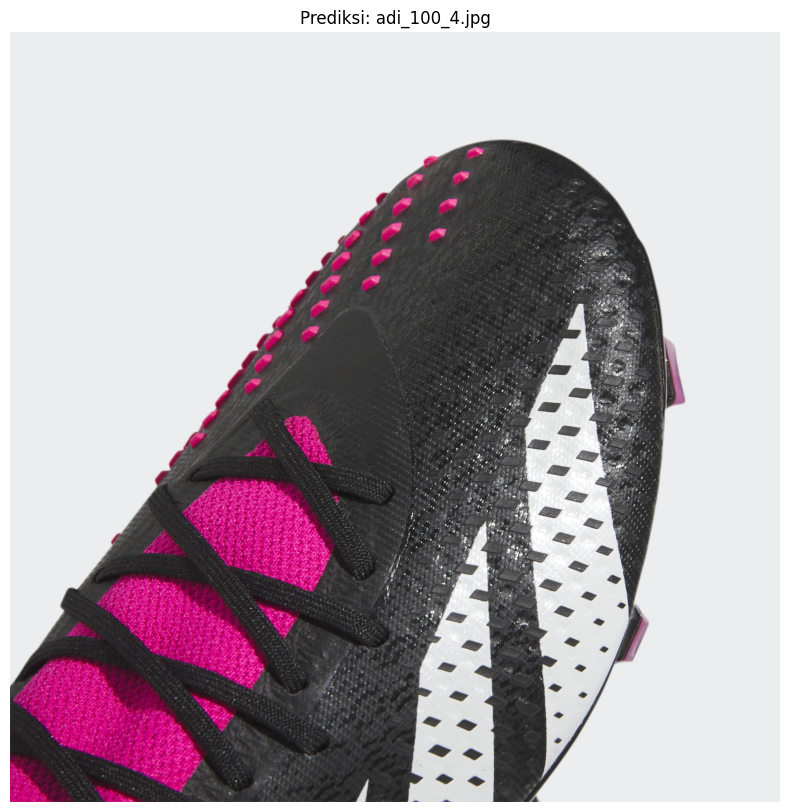

Deteksi found:
boxes: torch.Size([2, 4])
labels: torch.Size([2])
scores: torch.Size([2])
masks: torch.Size([2, 1, 2400, 2400])


In [ ]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
import sys

# Menambahkan path ke sys.path
sys.path.append('/content/fashionfail/src/fashionfail')

from models.facere import facere_base

# 1. Cari checkpoint terbaru
checkpoint_dir = './saved_models/'
checkpoint_path = os.path.join(checkpoint_dir, 'last.ckpt')

if not os.path.exists(checkpoint_path):
    import glob
    checkpoints = glob.glob(os.path.join(checkpoint_dir, '*.ckpt'))
    if checkpoints:
        checkpoint_path = sorted(checkpoints)[-1]
    else:
        checkpoint_path = None

print(f"Menggunakan checkpoint: {checkpoint_path}")

if checkpoint_path:
    # 2. Load Model
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = facere_base.load_from_checkpoint(checkpoint_path)
    model.to(device)
    model.eval()

    # 3. Ambil satu gambar contoh dari folder validasi
    val_img_dir = '/content/fashion_dataset/images/val'
    if os.path.exists(val_img_dir):
        sample_img_name = os.listdir(val_img_dir)[0]
        img_path = os.path.join(val_img_dir, sample_img_name)
        img = Image.open(img_path).convert("RGB")

        # 4. Prediksi
        with torch.no_grad():
            from torchvision.transforms import functional as F
            img_tensor = F.to_tensor(img).to(device)
            prediction = model([img_tensor])

        # 5. Tampilkan Hasil
        print(f"Hasil prediksi untuk: {sample_img_name}")
        plt.figure(figsize=(10,10))
        plt.imshow(img)
        plt.title(f"Prediksi: {sample_img_name}")
        plt.axis('off')
        plt.show()

        # Print deteksi (boxes, labels, scores)
        if len(prediction) > 0:
            print("Deteksi found:")
            for key, value in prediction[0].items():
                if isinstance(value, torch.Tensor):
                    print(f"{key}: {value.shape}")
        else:
            print("Tidak ada objek terdeteksi.")
    else:
        print(f"Error: Folder {val_img_dir} tidak ditemukan.")
else:
    print("Error: Tidak ditemukan file checkpoint di ./saved_models/")

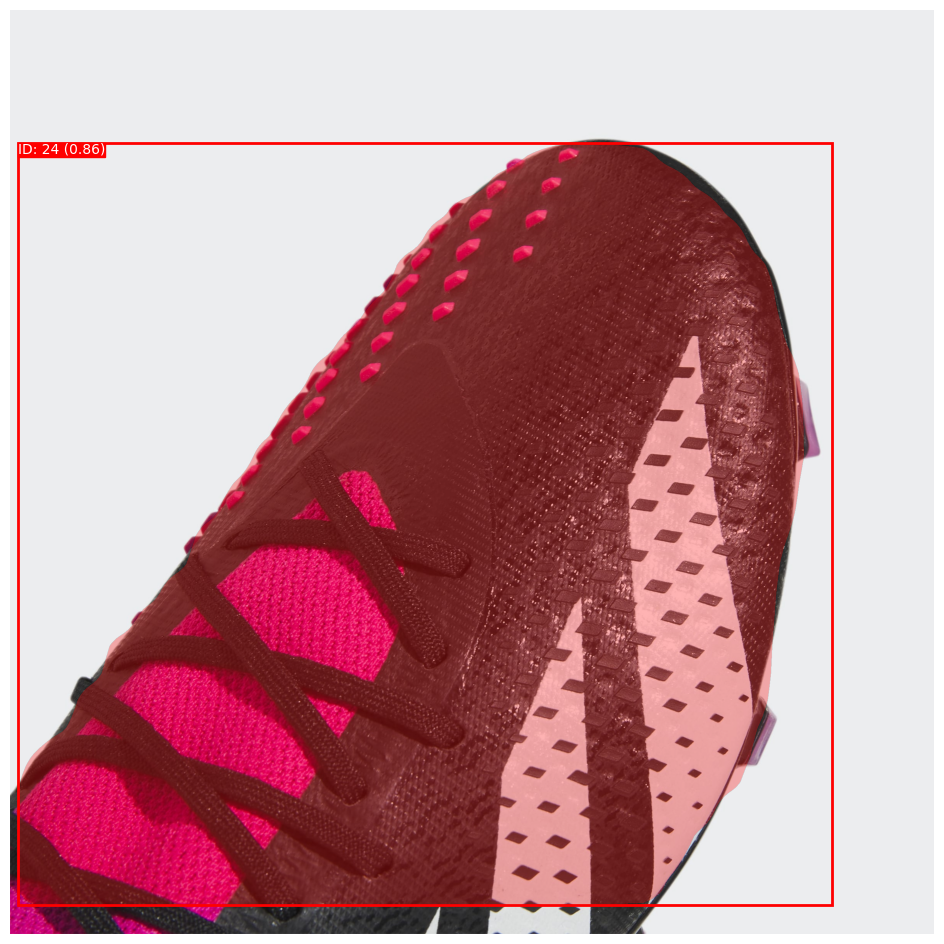

In [ ]:
import matplotlib.patches as patches

def visualize_prediction(image, prediction, threshold=0.5):
    plt.figure(figsize=(12, 12))
    plt.imshow(image)
    ax = plt.gca()

    # Ambil data dari prediksi pertama dalam batch
    pred = prediction[0]
    boxes = pred['boxes'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()
    masks = pred['masks'].cpu().numpy()

    for i in range(len(scores)):
        if scores[i] > threshold:
            # Gambar Box
            box = boxes[i]
            rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1],
                                   linewidth=2, edgecolor='r', facecolor='none')
            ax.add_patch(rect)

            # Gambar Mask (semi-transparan)
            mask = masks[i, 0] > 0.5
            mask_img = np.zeros((mask.shape[0], mask.shape[1], 4))
            mask_img[mask] = [1, 0, 0, 0.3] # Merah transparan
            plt.imshow(mask_img)

            plt.text(box[0], box[1], f'ID: {labels[i]} ({scores[i]:.2f})',
                     color='white', verticalalignment='top',
                     bbox={'color': 'red', 'pad': 0})

    plt.axis('off')
    plt.show()

# Panggil fungsi visualisasi
if 'img' in locals() and 'prediction' in locals():
    visualize_prediction(img, prediction, threshold=0.1) # Threshold rendah karena baru 1 epoch

### Batas Atas

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="AEv2gmGnbZGM6lD9XzWH")
project = rf.workspace("symphoenixs-workspace").project("Attributes Uniform")
dataset = project.version(1).download("coco")

### Contoh Logika 'Crop' untuk Pipeline Two-Step
Kode di bawah ini menunjukkan cara mengambil hasil deteksi (bounding box) dan memotongnya menjadi gambar kecil yang siap dikirim ke model klasifikasi warna.

* HOLD DULU, INI CUMA CONTOH! nih link dataset model kalsifikasi warna: https://www.kaggle.com/datasets/imoore/6000-store-items-images-classified-by-color/code






In [ ]:
# HOLD DULU, INI CUMA CONTOH!
import numpy as np
from PIL import Image

def get_cropped_objects(image, prediction, threshold=0.5):
    cropped_images = []
    pred = prediction[0]
    boxes = pred['boxes'].cpu().numpy()
    scores = pred['scores'].cpu().numpy()
    labels = pred['labels'].cpu().numpy()

    for i in range(len(scores)):
        if scores[i] > threshold:
            # Koordinat box [x1, y1, x2, y2]
            box = boxes[i].astype(int)
            # Crop menggunakan PIL (left, top, right, bottom)
            cropped_img = image.crop((box[0], box[1], box[2], box[3]))
            cropped_images.append({
                'label_id': labels[i],
                'confidence': scores[i],
                'image': cropped_img
            })
    return cropped_images

# Simulasi menjalankan crop pada hasil prediksi sebelumnya
if 'img' in locals() and 'prediction' in locals():
    crops = get_cropped_objects(img, prediction, threshold=0.1)

    print(f"Berhasil memotong {len(crops)} objek untuk diperiksa warnanya:")
    for i, item in enumerate(crops):
        plt.subplot(1, len(crops), i+1)
        plt.imshow(item['image'])
        plt.title(f"Objek {i}\nID:{item['label_id']}")
        plt.axis('off')
    plt.show()

### Struktur Dataset Kustom (Saran)
Untuk mendeteksi seragam SMA Nasional, Anda bisa menyiapkan data dengan struktur seperti ini sebelum di-upload ke Colab atau Roboflow:

1. **Kategori/Labels:**
   - `baju_putih`: Kemeja seragam.
   - `celana_abu`: Celana panjang SMA.
   - `topi_pet_sma`: Topi pet abu-abu SMA.
   - `dasi_sma`: Dasi abu-abu SMA.
   - `sepatu_hitam`: Sespatu hitam siswa.

2. **Format Data:**
   - Simpan gambar dalam folder `images/`.
   - Simpan anotasi (hasil dari Roboflow) dalam format `JSON (COCO format)` agar kompatibel dengan project ini.

### Batas Bawah


In [ ]:
import os
import json

image_dir = '/content/fashion_dataset/images'

# Memastikan direktori ada sebelum listdir
if os.path.exists(image_dir):
    existing_images = os.listdir(image_dir)
    print(f'Jumlah gambar di folder: {len(existing_images)}')
else:
    print(f'Peringatan: Folder {image_dir} tidak ditemukan.')

# Memeriksa entri di file anotasi
train_ann_path = '/content/fashion_dataset/ff_train.json'
if os.path.exists(train_ann_path):
    with open(train_ann_path, 'r') as f:
        data = json.load(f)
    print(f'Jumlah gambar di anotasi: {len(data["images"])}')
else:
    print(f'Peringatan: File anotasi {train_ann_path} tidak ditemukan.')

# Mencek sampel spesifik jika folder ada
missing_sample = 'adi_10145_1.jpg'
if os.path.exists(image_dir):
    print(f'Apakah {missing_sample} ada? {os.path.exists(os.path.join(image_dir, missing_sample))}')

Peringatan: Folder /content/fashion_dataset/images tidak ditemukan.
Peringatan: File anotasi /content/fashion_dataset/ff_train.json tidak ditemukan.


In [ ]:
import os
import json

# Memeriksa jumlah gambar yang ada
image_dir = '/content/fashion_dataset/images'
existing_images = os.listdir(image_dir)
print(f'Jumlah gambar di folder: {len(existing_images)}')

# Memeriksa entri di file anotasi
train_ann_path = '/content/fashion_dataset/ff_train.json'
with open(train_ann_path, 'r') as f:
    data = json.load(f)

print(f'Jumlah gambar di anotasi: {len(data["images"])}')

# Mencek apakah file yang error tadi benar-benar hilang
missing_sample = 'adi_10145_1.jpg'
print(f'Apakah {missing_sample} ada? {os.path.exists(os.path.join(image_dir, missing_sample))}')

Jumlah gambar di folder: 3
Jumlah gambar di anotasi: 1344
Apakah adi_10145_1.jpg ada? False


In [ ]:
!ls -R /content/fashion_dataset/images | head -n 20
!find /content/fashion_dataset/images -maxdepth 2 -type d

/content/fashion_dataset/images:
test
train
val

/content/fashion_dataset/images/test:
adi_10000_2.jpg
adi_1000_1.jpg
adi_10002_1.jpg
adi_10002_2.jpg
adi_10002_3.jpg
adi_10002_7.jpg
adi_1000_2.jpg
adi_10005_2.jpg
adi_10005_7.jpg
adi_10006_3.jpg
adi_10006_4.jpg
adi_10006_7.jpg
adi_10009_1.jpg
adi_10009_3.jpg
/content/fashion_dataset/images
/content/fashion_dataset/images/val
/content/fashion_dataset/images/train
/content/fashion_dataset/images/test


In [ ]:
import json
import os
from pathlib import Path

def filter_annotations(ann_path, base_img_dir):
    if not os.path.exists(ann_path):
        print(f'File {ann_path} not found.')
        return

    with open(ann_path, 'r') as f:
        data = json.load(f)

    # Walk through all subdirectories to find existing images
    existing_imgs = {}
    for root, dirs, files in os.walk(base_img_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                # Store mapping of filename to its relative path from base_img_dir
                existing_imgs[f] = os.path.relpath(os.path.join(root, f), base_img_dir)

    # Filter images list
    valid_image_ids = set()
    new_images = []
    for img in data.get('images', []):
        file_name = os.path.basename(img['file_name'])
        if file_name in existing_imgs:
            # Update file_name in annotation to the correct relative path
            img['file_name'] = existing_imgs[file_name]
            new_images.append(img)
            valid_image_ids.add(img['id'])

    # Filter annotations list
    new_annotations = [ann for ann in data.get('annotations', []) if ann['image_id'] in valid_image_ids]

    data['images'] = new_images
    data['annotations'] = new_annotations

    with open(ann_path, 'w') as f:
        json.dump(data, f)

    print(f'Filtered {ann_path}: {len(new_images)} images remaining.')

# Filter train and val annotations
filter_annotations('/content/fashion_dataset/ff_train.json', '/content/fashion_dataset/images')
filter_annotations('/content/fashion_dataset/ff_val.json', '/content/fashion_dataset/images')

Filtered /content/fashion_dataset/ff_train.json: 1326 images remaining.
Filtered /content/fashion_dataset/ff_val.json: 148 images remaining.


In [ ]:
import json
import os
from pathlib import Path

def filter_annotations(ann_path, base_img_dir):
    if not os.path.exists(ann_path):
        print(f'File {ann_path} not found.')
        return

    with open(ann_path, 'r') as f:
        data = json.load(f)

    # Walk through all subdirectories to find existing images
    existing_imgs = {}
    for root, dirs, files in os.walk(base_img_dir):
        for f in files:
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                # Store mapping of filename to its relative path from base_img_dir
                existing_imgs[f] = os.path.relpath(os.path.join(root, f), base_img_dir)

    # Filter images list
    valid_image_ids = set()
    new_images = []
    for img in data.get('images', []):
        file_name = os.path.basename(img['file_name'])
        if file_name in existing_imgs:
            # Update file_name in annotation to the correct relative path
            img['file_name'] = existing_imgs[file_name]
            new_images.append(img)
            valid_image_ids.add(img['id'])

    # Filter annotations list
    new_annotations = [ann for ann in data.get('annotations', []) if ann['image_id'] in valid_image_ids]

    data['images'] = new_images
    data['annotations'] = new_annotations

    with open(ann_path, 'w') as f:
        json.dump(data, f)

    print(f'Filtered {ann_path}: {len(new_images)} images remaining.')

# Filter train and val annotations
filter_annotations('/content/fashion_dataset/ff_train.json', '/content/fashion_dataset/images')
filter_annotations('/content/fashion_dataset/ff_val.json', '/content/fashion_dataset/images')

Filtered /content/fashion_dataset/ff_train.json: 1326 images remaining.
Filtered /content/fashion_dataset/ff_val.json: 148 images remaining.
